In [2]:
import pandas
from dataset import BraindumpDataset, split_dataset
from tokenizer import Tokenizer
import torch
%load_ext autoreload
%autoreload 2

In [3]:
df = pandas.read_csv("dataset_10000.csv")
df.head(10)

,input_text,target_text
0,Please remember to deploy the container and fi...,1. Deploy the container | 2. fix the leaky faucet
1,"I have to fix the leaky faucet, book the trave...",1. Fix the leaky faucet | 2. book the travel |...
2,"as we discussed, Please backup the photos, dep...",1. Backup the photos | 2. deploy the container...
3,"Please scan the receipts, test the new feature...",1. Scan the receipts | 2. test the new feature...
4,"the team needs, My tasks: Schedule a meeting w...",1. Schedule a meeting with luis | 2. water the...
5,"I have to update the repository, change the li...",1. Update the repository | 2. change the light...
6,"it's urgent, Please remember to charge the dev...",1. Charge the devices | 2. install the updates...
7,We have to configure the firewall and test the...,1. Configure the firewall | 2. test the new fe...
8,Don't forget to sweep the floor this weekend a...,1. Sweep the floor this weekend | 2. test the ...
9,Remind me to empty the recycle bin at noon and...,1. Empty the recycle bin at noon | 2. do the l...


In [4]:
all_text = " ".join(df['input_text'].astype(str).tolist() + df['target_text'].astype(str).tolist())
tokenizer = Tokenizer(all_text)

In [5]:
for input_text, target_text in zip(df['input_text'], df['target_text']):
    input_ids = tokenizer.encode(input_text)
    target_ids = tokenizer.encode(target_text)
    inputs_words = tokenizer.decode(input_ids)
    print(f"Input IDs: {input_ids}")
    print(f"Target IDs: {target_ids}")
    print(f"Input words: {inputs_words}")
    break
    

Input IDs: [183, 200, 241, 76, 237, 67, 21, 103, 237, 141, 97, 6, 2]
Target IDs: [7, 6, 76, 237, 67, 269, 8, 6, 103, 237, 141, 97, 2]
Input words: please remember to deploy the container and fix the leaky faucet.


In [6]:
def encode_row(text):
    return tokenizer.encode(text)

df['input_ids'] = df['input_text'].apply(encode_row)
df['target_ids'] = df['target_text'].apply(encode_row)
dataset = BraindumpDataset(df)


In [7]:
tokenizer.decode(df['input_ids'][2]), df['input_text'][2]

('as we discussed, please backup the photos, deploy the container, and schedule a meeting with el cliente.',
 'as we discussed, Please backup the photos, deploy the container, and schedule a meeting with el cliente.')

In [8]:
tokenizer.decode(df['target_ids'][2]), df['target_text'][2]

('1. backup the photos | 2. deploy the container | 3. meet with el cliente',
 '1. Backup the photos | 2. deploy the container | 3. Meet with el cliente')

In [9]:
#Need to Add Padding becuase there is a difference in Sequence Lenght input vs label
print(len(dataset[1][0]), len(dataset[1][1]))

20 19


In [10]:
train_dataset, val_dataset, test_dataset = split_dataset(dataset, 32)
len(train_dataset), len(val_dataset), len(test_dataset)

(250, 32, 32)

In [11]:
trainer_loader = iter(train_dataset)
batch_trainer = next(trainer_loader)
[len(i) for i in batch_trainer['tokenized_input']][0], [len(i) for i in batch_trainer['label']][0]

(26, 21)

In [12]:
validation_loader = iter(val_dataset)
batch2 = next(validation_loader)
[len(i) for i in batch2['tokenized_input']][0], [len(i) for i in batch2['label']][0]

(24, 20)

In [13]:
test_loader = iter(test_dataset)
batch_test = next(test_loader)
[len(i) for i in batch_test['tokenized_input']][0], [len(i) for i in batch_test['label']][0]

(31, 23)

## Training the Model Seq2Seq

In [14]:
from models.seq2seq_baseline import Encoder, Decoder, Seq2Seq
import torch.nn as nn
import torch.optim as optim
from utils import init_weights, plot_weights_initialization, count_parameters_model
import tqdm as notebook_tqdm
import tqdm
import numpy as np

In [15]:
input_dim = tokenizer.get_vocab_size()
output_dim = tokenizer.get_vocab_size()
assert input_dim == output_dim, "Encoder and Decoder must have the same vocabulary size because they share the same tokenizer"

encoder_hidden_dim = 128
decoder_hidden_dim = 128

hidden_dim = 312
n_layers = 3

encoder_dropout = 0.4
decoder_dropout = 0.4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(
    input_dim=input_dim,
    embedding_dim=encoder_hidden_dim,
    hidden_dim=hidden_dim,
    n_layers=n_layers,
    dropout=encoder_dropout
)

decoder = Decoder(
    output_dim=output_dim,
    embedding_dim=decoder_hidden_dim,
    hidden_dim=hidden_dim,
    n_layers=n_layers,
    dropout=decoder_dropout
)

Seq2Seq_model = Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    device=device
)

### Weight initialization

In the paper the state the initialization of the weights from a uniform distribution of -0.08 and 0.08


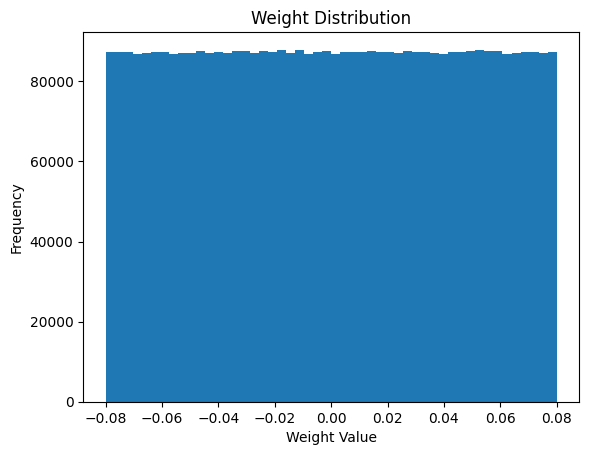

In [16]:
Seq2Seq_model.apply(init_weights)

plot_weights_initialization(Seq2Seq_model) #Plot initialization for seeing the distribution of the weihgts
    

In [17]:
sum_parameters = count_parameters_model(Seq2Seq_model)
print(f"The total parameters of the model {sum_parameters}")

The total parameters of the model 4381854


#### Optimizer

In [18]:
optimizer = optim.AdamW(Seq2Seq_model.parameters(), weight_decay=0.001)

#### Loss Function

The CrossEntropyLoss function calculates both the log softmax as well as the negative log-likelihood of our predictions.

In [19]:
pad_idx = 0 #Its zero because in the custom_collate, I'm adding 0's for the padding of the sequences
criterion = nn.CrossEntropyLoss(ignore_index = pad_idx)

#### Training Loop

At each iteration:

1. Get the source and target sentences from the batch, and zero the gradients calculated from the last batch.
2. Feed the source and target into the model to get the output.
3. As the loss function only works on 2D inputs with 1D targets, we need to flatten each of them with `.view`.
4. We slice off the first column of the output and target tensors as mentioned above.
5. Calculate the gradients with `loss.backward()`.
6. Clip the gradients to prevent them from exploding (a common issue in RNNs).
7. Update the parameters of our model by doing an optimizer step.
8. Sum the loss value to a running total.

In [20]:
from utils import train_fuction, validation_fuction
import matplotlib.pyplot as plt
from EarlyStopping import EarlyStopping


In [20]:
n_epochs = 50
clip = 1.0
n_num_epochs = 0
teacher_forcing_ratio = 0.5
best_valid_loss = float('inf')
train_losses = []
validation_losses = []

earlystopping = EarlyStopping(patience=2, mode="min", path="best_baseline_model.pt", verbose=True)


for epoch in tqdm.tqdm(range(n_epochs)):
    train_loss = train_fuction(
        Seq2Seq_model,
        train_dataset,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device)
    validation_loss = validation_fuction(
        Seq2Seq_model,
        val_dataset,
        criterion,
        device
    )
    
    train_losses.append(train_loss)
    validation_losses.append(validation_loss)
    
    earlystopping(validation_loss, Seq2Seq_model)
    n_num_epochs +=1
    
    if earlystopping.early_stop:
            print("Finished because of the early Stopping")
            break
    print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
    print(f"\tValid Loss: {validation_loss:7.3f} | Valid PPL: {np.exp(validation_loss):7.3f}")




  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [01:40<1:21:49, 100.20s/it]

New best metric for Seq2Seq model 2.7839 -> New model
	Train Loss:   3.184 | Train PPL:  24.138
	Valid Loss:   2.784 | Valid PPL:  16.182


  4%|▍         | 2/50 [03:18<1:19:21, 99.20s/it] 

New best metric for Seq2Seq model 2.3997 -> New model
	Train Loss:   2.665 | Train PPL:  14.365
	Valid Loss:   2.400 | Valid PPL:  11.020


...

New best metric for Seq2Seq model 0.4712 -> New model
	Train Loss:   0.477 | Train PPL:   1.611
	Valid Loss:   0.471 | Valid PPL:   1.602


 74%|███████▍  | 37/50 [1:11:53<24:22, 112.47s/it]

EarlyStopping counter 1/2
	Train Loss:   0.483 | Train PPL:   1.621
	Valid Loss:   0.494 | Valid PPL:   1.639


 74%|███████▍  | 37/50 [1:13:38<25:52, 119.43s/it]

EarlyStopping counter 2/2
Finished because of the early Stopping


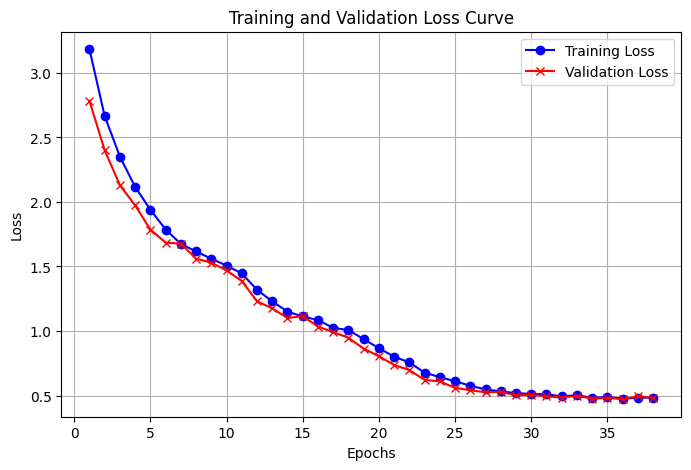

In [21]:
epochs_range = range(1, n_num_epochs + 1)


plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, validation_losses, label='Validation Loss', color='red', marker='x')

plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Evaluating the model

In [22]:
from rouge_score import rouge_scorer
from torch.utils.data import DataLoader
from tqdm import tqdm

In [21]:

Seq2Seq_model.load_state_dict(torch.load("best_baseline_model.pt", map_location=device))

test_loss = validation_fuction(
    Seq2Seq_model,
    test_dataset,  
    criterion,
    device
)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

| Test Loss: 0.461 | Test PPL:   1.585 |


In [22]:
from utils import predict_LSTM

### Without Attention

In [23]:
frases = [
    "Schedule a meeting with Sarah by Friday and remember to run the database backup",
    "Buy milk, eggs, and bread from the grocery store tomorrow morning",
    "Don't let me forget to buy protein powder, it's urgent! And water the plants."
]

for texto in frases:
    resultado = predict_LSTM(
        sentence=texto,
        model=Seq2Seq_model,
        tokenizer=tokenizer,
        device=device,
        max_output_length=30
    )
    print(f"Prompt: {texto}")
    print(f"Completion:  {resultado}")

Prompt: Schedule a meeting with Sarah by Friday and remember to run the database backup
Completion:  . schedule a meeting with carlos this today | 2. run the database backup
Prompt: Buy milk, eggs, and bread from the grocery store tomorrow morning
Completion:  . buy batteries | 2. clean the bathroom | 3. meet with sarah
Prompt: Don't let me forget to buy protein powder, it's urgent! And water the plants.
Completion:  . buy protein powder | 2. respond to emails | 3. meet with sarah


In [24]:
import evaluate

rouge = evaluate.load('rouge')
bleu = evaluate.load('bleu')


predictions = []
references = []


for ejemplo in test_dataset:
    
    input_ids = ejemplo['tokenized_input']
    target_ids = ejemplo['label']
    
    
    if isinstance(input_ids, torch.Tensor):
        input_text = tokenizer.decode(input_ids)
    else:
        input_text = str(input_ids)
        
    
    if isinstance(target_ids, torch.Tensor):
        target_text = tokenizer.decode(target_ids)
    else:
        target_text = str(target_ids)
        
    
    resultado = predict_LSTM(
        sentence=input_text,  
        model=Seq2Seq_model,
        tokenizer=tokenizer,
        device=device,
        max_output_length=50
    )
    
    predictions.append(resultado)
    references.append(target_text)

print(f"Total predictions generated: {len(predictions)}")
print(f"Total references captured: {len(references)}")


Total predictions generated: 32
Total references captured: 32


In [25]:
import evaluate

rouge = evaluate.load('rouge')
bleu = evaluate.load('bleu')


rouge_results = rouge.compute(
    predictions=predictions, 
    references=references,
    use_stemmer=True
)


bleu_results = bleu.compute(
    predictions=predictions, 
    references=references
)

In [26]:
print("--- Rogue Results---")
rouge_results

--- Rogue Results---


{'rouge1': 0.8768988156049459,
 'rouge2': 0.845715368627558,
 'rougeL': 0.8767406426215857,
 'rougeLsum': 0.8774601078260433}

In [27]:
print("\n--- Blue Results ---")
bleu_results


--- Blue Results ---


{'bleu': 0.848478826116751,
 'precisions': [0.9312638580931264,
  0.9093078758949881,
  0.8863049095607235,
  0.8619718309859155],
 'brevity_penalty': 0.9460760022566528,
 'length_ratio': 0.9474789915966386,
 'translation_length': 451,
 'reference_length': 476}